# LVC (2× CAC) — IVol Regime Filter

**Instrument:** LVC — Amundi ETF Leveraged CAC 40 (2× daily)  
**Signal source:** CAC 40 Implied Volatility (sfera_db)  
**Idea:** exit to cash when IVol signals elevated risk; re-enter when volatility normalises  
**Data:** LVC_daily.xlsx (Euronext/Bloomberg) — full history from 2008, correct GFC prices


In [1]:
import sys, subprocess
import pandas as pd, numpy as np
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

_REPO = Path(subprocess.check_output(
    'git rev-parse --show-toplevel', shell=True, text=True, cwd='.'
).strip())
DATA = _REPO / 'data'
PROJECT_ROOT = _REPO

try:
    from signum import Chart, Dashboard
except ImportError:
    sys.path.insert(0, str(_REPO.parent / 'signum'))
    from signum import Chart, Dashboard

try:
    import sfera_db
    _SFERA_AVAILABLE = True
except ImportError:
    _SFERA_AVAILABLE = False
    print("sfera_db not available — using CSV snapshots (see data/lev_etf/SETUP.md)")
import ipywidgets as widgets
from IPython.display import display

In [2]:

# ── Load CAC (price, ivol, total return) ──
if _SFERA_AVAILABLE:
    cac_px   = sfera_db.index_prices('CAC')[['close', 'volume']]
    cac_ivol = sfera_db.index_ivol('CAC')[['ivol']]
    try:
        cac_tr_raw = sfera_db.read_table('index_total_return', ticker='CACT')[['close_price']]
        cac_tr_px  = cac_tr_raw.rename(columns={'close_price': 'close'})
        has_tr = True
    except Exception:
        cac_tr_px = None; has_tr = False
else:
    cac_px   = pd.read_csv(DATA / 'c40_ohlcv.csv',          parse_dates=['date'], index_col='date')[['close', 'volume']]
    cac_ivol = pd.read_csv(DATA / 'lev_etf' / 'cac_ivol.csv', parse_dates=['date'], index_col='date')[['ivol']]
    cac_tr_px = pd.read_csv(DATA / 'cactr_ohlcv.csv',        parse_dates=['date'], index_col='date')[['close']]
    has_tr = True

common_idx = cac_px.index.intersection(cac_ivol.index)
if has_tr:
    common_idx = common_idx.intersection(cac_tr_px.index)

cac = pd.DataFrame({'close': cac_px.loc[common_idx, 'close'],
                    'ivol':  cac_ivol.loc[common_idx, 'ivol']}).sort_index()
cac['ret'] = cac['close'].pct_change()
if has_tr:
    cac['close_tr'] = cac_tr_px.loc[common_idx, 'close']
    cac['ret_tr']   = cac['close_tr'].pct_change()
    clean = cac.dropna(subset=['ret', 'ret_tr']).copy()
else:
    cac['ret_tr'] = cac['ret']
    clean = cac.dropna(subset=['ret']).copy()
clean['ivol_ema5']  = clean['ivol'].ewm(span=5).mean()
clean['ivol_ema20'] = clean['ivol'].ewm(span=20).mean()

# ── Load LVC (2x CAC, Amundi) — full history from 2008 ──
lvc_raw = (
    pd.read_csv(DATA / 'lev_etf' / 'lvc_daily.csv', parse_dates=['date'])
    .set_index('date').sort_index()
)
common_lvc = clean.index.intersection(lvc_raw.index)
lvc = pd.DataFrame({
    'close': lvc_raw.loc[common_lvc, 'close'],
    'ivol':  clean.loc[common_lvc, 'ivol'],
    'ret':   lvc_raw.loc[common_lvc, 'close'].pct_change(),
}).dropna()
lvc_bh_eq     = (1 + lvc['ret']).cumprod()
lvc_bh_sharpe = lvc['ret'].mean() / lvc['ret'].std() * np.sqrt(252)
print(f"Data source    : {'sfera_db (live)' if _SFERA_AVAILABLE else 'CSV snapshots'}")
print(f"LVC date range : {lvc.index[0].date()} -> {lvc.index[-1].date()}  ({len(lvc)} days)")
print(f"LVC B&H  Sharpe {lvc_bh_sharpe:.3f}  Total {(lvc_bh_eq.iloc[-1]-1)*100:+.1f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Personal\\Business & Investments\\Trading portfolio\\Strategies\\ETF TKAN\\Data\\Archive\\LVC_daily.xlsx'

In [ ]:

# ── LVC (2× CAC) IVol threshold explorer (Signum — pure JS, no Python callbacks) ──
# Convention: signal = −IVol so that "−IVol ≥ −θ"  ↔  "IVol < θ"  (= long).
# Drag the θ slider → price-pane shading, equity curve, and stats all update live.

lvc_bh_eq     = (1 + lvc['ret']).cumprod()
lvc_bh_sharpe = lvc['ret'].mean() / lvc['ret'].std() * np.sqrt(252)
print(f"LVC B&H  Sharpe {lvc_bh_sharpe:.3f}  Total {(lvc_bh_eq.iloc[-1]-1)*100:+.1f}%")

ivol_min_l = int(lvc['ivol'].min())
ivol_max_l = int(lvc['ivol'].max()) + 1
ivol_p70_l = int(lvc['ivol'].quantile(0.70))

t_l = lvc.index

# Negated IVol: standard ">= threshold" direction means long when IVol < threshold
sig_lvc   = pd.DataFrame({'time': t_l, 'value': -lvc['ivol'].values})
lvc_px_df = pd.DataFrame({'time': t_l, 'value': lvc['close'].values})

p_price_l  = Chart(height=300).line(lvc_px_df, name='LVC 2×', color='#a78bfa', width=2)
p_signal_l = Chart(height=200).baseline(sig_lvc)
p_eq_l = (
    Chart(height=180)
    .line(pd.DataFrame({'time': t_l, 'value': lvc_bh_eq.values}),
          name='Strategy', color='#34d399', width=2)
    .line(pd.DataFrame({'time': t_l, 'value': lvc_bh_eq.values}),
          name='LVC B&H', color='#6b7280', width=1)
)

Dashboard(
    panes=[p_price_l, p_signal_l, p_eq_l],
    titles=[
        'LVC 2× — drag θ to set LVC IVol exit threshold  (green shading = in market)',
        '−IVol signal  (above θ = long, below = flat)',
        'Equity — Strategy vs LVC B&H  (indexed 100)',
    ],
    theme='dark'
).threshold_control(
    sig_lvc,
    threshold=-ivol_p70_l,
    min_val=-ivol_max_l,
    max_val=-ivol_min_l,
    step=1,
    price_pane=0,
    daily_returns=lvc['ret'].shift(-1).fillna(0),  # 1-day lag: signal@close[T] → trade@close[T+1]
    bh_returns=lvc['ret'],
    equity_pane=2,
)


LVC B&H  Sharpe 0.318  Total +126.1%


## Fixed IVol Threshold — LVC

**Exiting LVC when CAC IVol ≥ ~40–45 meaningfully improves risk-adjusted returns** (Sharpe ~0.37 vs B&H baseline). The leverage doubles drawdown severity during high-IVol regimes, so avoiding them outweighs the cost of missed upside — an effect that doesn't show up on the unleveraged index.

**Next:** dynamic thresholds (IVol Z-score, EMA crossover) that adapt to secular regime shifts.


## Dynamic IVol Signals — LVC

Five signal families tested. Default parameters in the comparison table; interactive explorer below.

| Signal | Long when… |
|---|---|
| Fixed level | IVol < X |
| IVol vs EMA(N) | IVol < its N-day EMA |
| IVol momentum(N) | N-day IVol change ≤ 0 |
| IVol Z-score(W) | rolling Z-score < 1.0 (regime-normalised) |
| EMA crossover(fast, slow=40) | EMA-fast < EMA-slow |


In [ ]:

# ── Dynamic signal helpers + comparison table ──

def _position(sig, p1, p2=None):
    ivol = lvc['ivol']
    if sig == 'Fixed level':
        return (ivol < p1).astype(float)
    elif sig == 'IVol vs EMA':
        return (ivol < ivol.ewm(span=int(p1)).mean()).astype(float)
    elif sig == 'IVol momentum':
        return (ivol.diff(int(p1)) <= 0).fillna(False).astype(float)
    elif sig == 'IVol Z-score':
        rm = ivol.rolling(int(p1)).mean()
        rs = ivol.rolling(int(p1)).std()
        return ((ivol - rm) / rs < float(p2)).fillna(True).astype(float)
    elif sig == 'EMA crossover':
        return (ivol.ewm(span=int(p1)).mean() < ivol.ewm(span=int(p2)).mean()).astype(float)

def _perf(pos):
    # lag=1 day: signal observed at close[T] → execute at open[T+1]
    # fillna(0) = stay flat (cash) until first valid signal is established
    lagged = pos.shift(1).fillna(0)
    sr  = lagged * lvc['ret']
    eq  = (1 + sr).cumprod()
    sh  = sr.mean() / sr.std() * np.sqrt(252) if sr.std() > 0 else 0
    mdd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    return {
        'Sharpe':    round(sh, 3),
        'Total %':   round((eq.iloc[-1] - 1) * 100, 1),
        'MaxDD %':   round(mdd, 1),
        '% in-mkt':  round(lagged.mean() * 100, 1),
        '_eq':       eq,
    }

# Default params for comparison table
DEFAULTS = [
    ('Fixed level',   42,   None, 'IVol < 42'),
    ('IVol vs EMA',   20,   None, 'IVol < EMA-20'),
    ('IVol momentum',  5,   None, 'Δ5d IVol ≤ 0'),
    ('IVol Z-score',  90,   1.0,  'Z(90d) < 1.0'),
    ('EMA crossover',  5,   40,   'EMA-5 < EMA-40'),
]

rows = []
for sig, p1, p2, desc in DEFAULTS:
    pos  = _position(sig, p1, p2)
    perf = _perf(pos)
    rows.append({'Signal': desc, **{k: v for k, v in perf.items() if not k.startswith('_')}})

bh_mdd_lvc = ((lvc_bh_eq - lvc_bh_eq.cummax()) / lvc_bh_eq.cummax()).min() * 100
rows.append({
    'Signal':   'LVC B&H',
    'Sharpe':   round(lvc_bh_sharpe, 3),
    'Total %':  round((lvc_bh_eq.iloc[-1] - 1) * 100, 1),
    'MaxDD %':  round(bh_mdd_lvc, 1),
    '% in-mkt': 100.0,
})

tbl = pd.DataFrame(rows).set_index('Signal')
display(
    tbl.style
    .background_gradient(subset=['Sharpe'], cmap='RdYlGn', vmin=0.0, vmax=0.6)
    .set_caption('Dynamic IVol Signals — LVC  (default parameters)')
    .format({'Sharpe': '{:.3f}', 'Total %': '{:+.1f}', 'MaxDD %': '{:.1f}', '% in-mkt': '{:.1f}'})
)


,Sharpe,Total %,MaxDD %,% in-mkt
Signal,,,,
IVol < 42,0.299,+103.6,-76.1,98.5
IVol < EMA-20,0.147,+7.9,-64.0,59.5
Δ5d IVol ≤ 0,0.033,-36.8,-86.7,54.0
Z(90d) < 1.0,0.296,+118.9,-61.6,80.5
EMA-5 < EMA-40,0.023,-37.4,-62.5,60.3
LVC B&H,0.318,+126.1,-75.2,100.0


In [ ]:

# ── Dynamic IVol signal explorer — LVC ──
# Dropdown picks signal type; p1 slider tunes the primary parameter.
# Secondary param (Z threshold / slow EMA period) is fixed at sensible defaults.

# p2 fixed defaults per signal (for explorer; table above used same values)
_P2_FIXED = {'Fixed level': None, 'IVol vs EMA': None,
             'IVol momentum': None, 'IVol Z-score': 1.0, 'EMA crossover': 40}

# p1 slider config per signal: (label, min, max, default, step)
_P1_CFG = {
    'Fixed level':   ('IVol threshold', 10,  79, 42, 1),
    'IVol vs EMA':   ('EMA period',      5, 120, 20, 1),
    'IVol momentum': ('Lookback days',   1,  30,  5, 1),
    'IVol Z-score':  ('Window days',    20, 252, 90, 5),
    'EMA crossover': ('Fast period',     2,  30,  5, 1),
}

dd_dyn = widgets.Dropdown(
    options=list(_P1_CFG.keys()), value='IVol vs EMA',
    description='Signal:', style={'description_width': '70px'},
    layout=widgets.Layout(width='45%')
)
sl_dyn = widgets.IntSlider(
    continuous_update=False,
    style={'description_width': '130px'},
    layout=widgets.Layout(width='70%')
)
out_dyn = widgets.Output()

def _apply_p1_cfg(sig):
    label, mn, mx, default, step = _P1_CFG[sig]
    # reset bounds safely before setting value
    sl_dyn.min, sl_dyn.max = 1, 10000
    sl_dyn.description = label
    sl_dyn.step = step
    sl_dyn.value = default
    sl_dyn.min, sl_dyn.max = mn, mx

_apply_p1_cfg(dd_dyn.value)

def _ivol_pane(sig, p1, pos_out):
    t = lvc.index
    ivol = lvc['ivol']
    c = (Chart(height=200)
         .line(pd.DataFrame({'time': t, 'value': ivol.values}),
               name='IVol', color='#fb923c', width=1)
         .shade(pos_out, position_col='position', color='#f87171', opacity=0.12))
    if sig == 'Fixed level':
        c = c.price_line(price=float(p1), title=f'{p1}',
                         color='#f87171', line_style=2, line_width=1)
    elif sig == 'IVol vs EMA':
        ema = ivol.ewm(span=int(p1)).mean()
        c = c.line(pd.DataFrame({'time': t, 'value': ema.values}),
                   name=f'EMA-{p1}', color='#a78bfa', width=1)
    elif sig == 'EMA crossover':
        ef = ivol.ewm(span=int(p1)).mean()
        es = ivol.ewm(span=40).mean()
        c = (c.line(pd.DataFrame({'time': t, 'value': ef.values}),
                    name=f'EMA-{p1}', color='#34d399', width=1)
              .line(pd.DataFrame({'time': t, 'value': es.values}),
                    name='EMA-40', color='#6b7280', width=1))
    elif sig == 'IVol Z-score':
        rm = ivol.rolling(int(p1)).mean()
        c = c.line(pd.DataFrame({'time': t, 'value': rm.values}),
                   name=f'Mean-{p1}d', color='#a78bfa', width=1)
    return c

def _draw_dyn(sig, p1):
    p2   = _P2_FIXED[sig]
    pos  = _position(sig, p1, p2)
    perf = _perf(pos)
    t    = lvc.index
    # lag=1 day: signal observed at close[T] → execute at open[T+1]
    # fillna(0) = stay flat (cash) until first valid signal is established
    lagged  = pos.shift(1).fillna(0)
    pos_in  = pd.DataFrame({'time': t, 'position': lagged.values})
    pos_out = pd.DataFrame({'time': t, 'position': (1 - lagged).values})

    p_price = (
        Chart(height=300)
        .line(pd.DataFrame({'time': t, 'value': lvc['close'].values}),
              name='LVC 2×', color='#a78bfa', width=2)
        .shade(pos_in, position_col='position', color='#34d399', opacity=0.08)
    )
    p_ivol_d = _ivol_pane(sig, p1, pos_out)
    p_eq = (
        Chart(height=180)
        .line(pd.DataFrame({'time': t, 'value': perf['_eq'].values}),
              name='Strategy', color='#34d399', width=2)
        .line(pd.DataFrame({'time': lvc_bh_eq.index, 'value': lvc_bh_eq.values}),
              name='LVC B&H', color='#6b7280', width=1)
    )
    p2_str = f'  p2={p2}' if p2 is not None else ''
    return Dashboard(
        panes=[p_price, p_ivol_d, p_eq],
        titles=[
            f'LVC 2×  —  {sig}  (p1={p1}{p2_str})  |  {perf["% in-mkt"]:.0f}% in market',
            'CAC Implied Volatility',
            f'Sharpe {perf["Sharpe"]:.3f}   Total {perf["Total %"]:+.1f}%   MaxDD {perf["MaxDD %"]:.1f}%',
        ],
        theme='dark'
    )

def _refresh_dyn(*_):
    with out_dyn:
        from IPython.display import clear_output
        clear_output(wait=True)
        display(_draw_dyn(dd_dyn.value, sl_dyn.value))

def _on_sig(change):
    _apply_p1_cfg(change['new'])
    _refresh_dyn()

dd_dyn.observe(_on_sig, names='value')
sl_dyn.observe(_refresh_dyn, names='value')

with out_dyn:
    display(_draw_dyn(dd_dyn.value, sl_dyn.value))

display(widgets.VBox([dd_dyn, sl_dyn, out_dyn]))


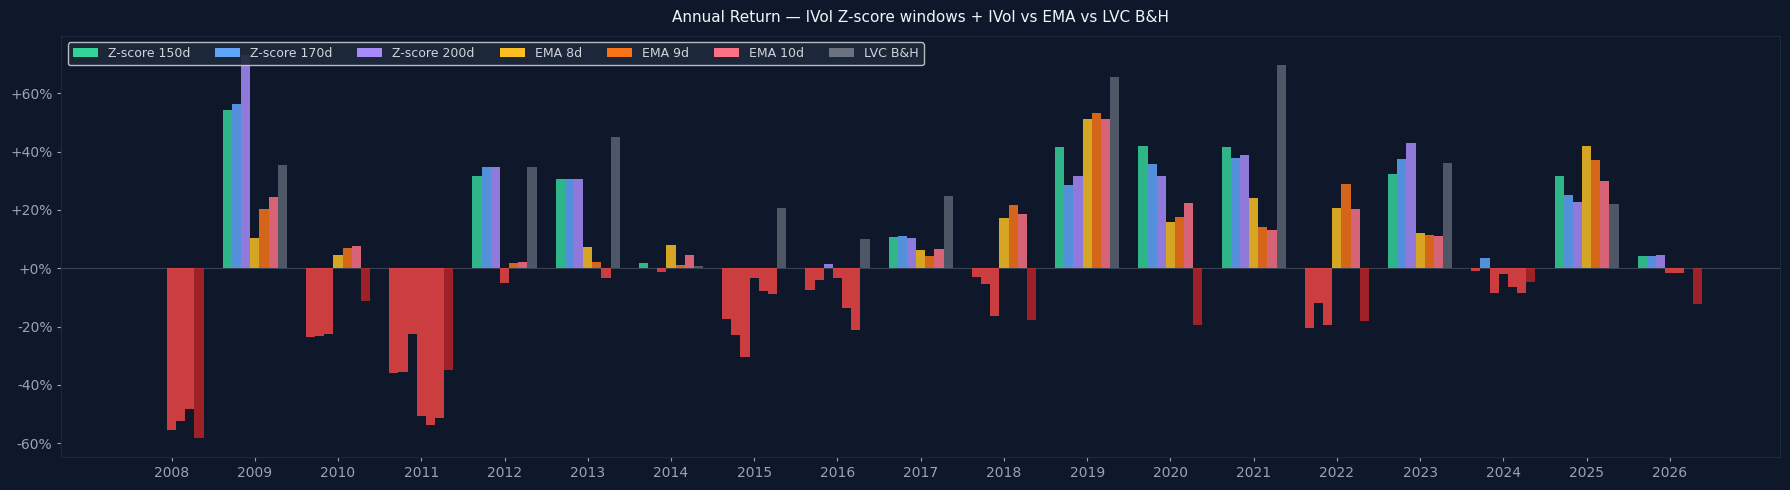

,LVC B&H %,CAC TR %,Z 150d %,Z 170d %,Z 200d %,EMA 8d %,EMA 9d %,EMA 10d %
2008,-58.2,-30.5,+0.0,+0.0,+0.0,-55.3,-52.4,-48.2
2009,+35.5,+27.6,+54.4,+56.2,+73.1,+10.2,+20.4,+24.3
2010,-11.1,+1.8,-23.6,-23.1,-22.6,+4.6,+7.1,+7.6
2011,-34.8,-14.4,-36.0,-35.4,-22.5,-50.5,-53.6,-51.4
2012,+34.9,+19.7,+31.6,+34.9,+34.9,-4.9,+1.9,+2.1
2013,+44.9,+22.9,+30.6,+30.6,+30.7,+7.4,+2.2,-3.4
2014,+0.7,+2.7,+1.8,+0.2,-1.3,+8.1,+1.1,+4.6
2015,+20.8,+13.5,-17.3,-22.7,-30.5,-3.5,-7.8,-9.0
2016,+9.9,+7.9,-7.3,-4.2,+1.3,-3.5,-13.7,-21.0
2017,+24.6,+12.7,+10.8,+11.0,+10.3,+6.4,+4.1,+6.7


,Total Return %,Ann. Vol %,Sharpe,IR vs LVC B&H
Strategy,,,,
Z 150d,+344.6,30.4,0.424,-0.012
Z 170d,+317.8,30.1,0.414,-0.028
Z 200d,+280.5,29.5,0.399,-0.051
EMA 8d,+31.5,26.7,0.191,-0.255
EMA 9d,+12.6,26.6,0.159,-0.282
EMA 10d,+5.2,26.5,0.144,-0.294
LVC B&H,+126.1,41.7,0.318,—
CAC TR,+194.9,21.4,0.387,—


,LVC B&H,Z 150d,Z 170d,Z 200d,EMA 8d,EMA 9d,EMA 10d
2008,-1.242,0.000,0.000,0.000,-2.905,-2.701,-2.404
2009,0.838,1.104,1.170,1.543,0.439,0.651,0.729
2010,-0.042,-0.627,-0.610,-0.591,0.300,0.390,0.410
2011,-0.472,-1.030,-1.052,-0.571,-1.618,-1.817,-1.707
2012,0.939,0.879,0.939,0.939,-0.031,0.208,0.214
2013,1.321,1.037,1.028,1.028,0.467,0.206,-0.088
2014,0.180,0.193,0.132,0.069,0.487,0.152,0.331
2015,0.646,-0.455,-0.659,-1.031,0.004,-0.177,-0.235
2016,0.434,-0.047,0.048,0.208,0.031,-0.351,-0.673
2017,1.154,0.657,0.665,0.625,0.503,0.355,0.525


,Z 150d,Z 170d,Z 200d,EMA 8d,EMA 9d,EMA 10d
2008,1.242,1.242,1.242,-0.235,-0.097,0.086
2009,0.983,0.553,0.592,-0.791,-0.527,-0.425
2010,-0.652,-0.628,-0.609,0.265,0.329,0.345
2011,-0.259,-0.241,0.158,-0.871,-1.018,-0.908
2012,-1.240,0.000,0.000,-1.372,-1.136,-1.129
2013,-1.021,-1.108,-1.163,-1.299,-1.531,-1.708
2014,-0.050,-0.123,-0.200,0.159,-0.110,0.024
2015,-1.351,-1.591,-1.892,-0.811,-0.930,-0.963
2016,-0.816,-0.673,-0.445,-0.579,-0.946,-1.218
2017,-1.162,-1.150,-1.253,-1.108,-1.244,-1.087


In [ ]:

# ── Annual PnL — IVol Z-score (150d / 170d / 200d) + IVol vs EMA (8d / 9d / 10d) vs LVC B&H ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

WINDOWS     = [150, 170, 200]
Z_COLORS    = ['#34d399', '#60a5fa', '#a78bfa']

EMA_PERIODS = [8, 9, 10]
EMA_COLORS  = ['#fbbf24', '#f97316', '#fb7185']

def _daily_ret(sig, p1, p2=None):
    pos = _position(sig, p1, p2)
    return pos.shift(1).fillna(0) * lvc['ret']

daily_z      = {w: _daily_ret('IVol Z-score', w, 1.0) for w in WINDOWS}
daily_ema    = {p: _daily_ret('IVol vs EMA',  p)      for p in EMA_PERIODS}
daily_bh     = lvc['ret']
daily_cac    = clean.loc[lvc.index, 'ret']
daily_cac_tr = clean.loc[lvc.index, 'ret_tr']

annual_z      = {w: (1 + daily_z[w]).resample('YE').prod() - 1   for w in WINDOWS}
annual_ema    = {p: (1 + daily_ema[p]).resample('YE').prod() - 1 for p in EMA_PERIODS}
annual_bh     = (1 + daily_bh).resample('YE').prod() - 1
annual_cac    = (1 + daily_cac).resample('YE').prod() - 1
annual_cac_tr = (1 + daily_cac_tr).resample('YE').prod() - 1
years         = annual_z[WINDOWS[0]].index.year

def total_return(dr):  return ((1 + dr).prod() - 1) * 100
def ann_vol(dr):       return dr.std() * np.sqrt(252) * 100
def total_sharpe(dr):  return dr.mean() / dr.std() * np.sqrt(252) if dr.std() > 0 else 0.0
def total_ir(dr, bh):
    exc = dr - bh
    return exc.mean() / exc.std() * np.sqrt(252) if exc.std() > 0 else 0.0
def per_year_sharpe(dr):
    return dr.groupby(dr.index.year).apply(
        lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0.0)
def per_year_ir(dr, bh):
    exc = dr - bh
    return exc.groupby(exc.index.year).apply(
        lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0.0)

# ── Bar chart ──
n_groups = len(WINDOWS) + len(EMA_PERIODS) + 1
bar_w    = 0.11
offsets  = np.linspace(-(n_groups - 1) / 2, (n_groups - 1) / 2, n_groups) * bar_w
x        = np.arange(len(years))

fig, ax = plt.subplots(figsize=(18, 5), facecolor='#0f172a')
ax.set_facecolor('#0f172a')
for k, (w, c, off) in enumerate(zip(WINDOWS, Z_COLORS, offsets[:len(WINDOWS)])):
    vals = annual_z[w].values * 100
    ax.bar(x + off, vals, width=bar_w, color=[c if v >= 0 else '#ef4444' for v in vals],
           alpha=0.85, zorder=2, label=f'Z {w}d')
for k, (p, c, off) in enumerate(zip(EMA_PERIODS, EMA_COLORS,
                                     offsets[len(WINDOWS):len(WINDOWS) + len(EMA_PERIODS)])):
    vals = annual_ema[p].values * 100
    ax.bar(x + off, vals, width=bar_w, color=[c if v >= 0 else '#ef4444' for v in vals],
           alpha=0.85, zorder=2, label=f'EMA {p}d')
bh_vals = annual_bh.values * 100
ax.bar(x + offsets[-1], bh_vals, width=bar_w,
       color=['#6b7280' if v >= 0 else '#dc2626' for v in bh_vals], alpha=0.70, zorder=2, label='LVC B&H')
ax.axhline(0, color='#374151', linewidth=0.8, zorder=1)
ax.set_xticks(x); ax.set_xticklabels(years, color='#d1d5db', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax.tick_params(colors='#9ca3af', length=3)
for spine in ax.spines.values(): spine.set_color('#1e293b')
legend_items  = [Patch(facecolor=c, label=f'Z-score {w}d') for w, c in zip(WINDOWS, Z_COLORS)]
legend_items += [Patch(facecolor=c, label=f'EMA {p}d')     for p, c in zip(EMA_PERIODS, EMA_COLORS)]
legend_items += [Patch(facecolor='#6b7280', label='LVC B&H')]
ax.legend(handles=legend_items, facecolor='#1e293b', labelcolor='#d1d5db',
          framealpha=0.9, fontsize=9, ncol=7, loc='upper left')
ax.set_title('Annual Return — IVol Z-score windows + IVol vs EMA vs LVC B&H',
             color='#f1f5f9', pad=10, fontsize=11)
plt.tight_layout(); plt.show()

# ── Annual return table ──
# Build with positional alignment (all series share the same DatetimeIndex),
# then replace with integer years — avoids index-mismatch NaN.
ret_cols_strat = [f'Z {w}d %' for w in WINDOWS] + [f'EMA {p}d %' for p in EMA_PERIODS]
tbl_data = {'LVC B&H %': (annual_bh * 100).round(1),
            'CAC TR %':  (annual_cac_tr * 100).round(1)}
for w in WINDOWS:     tbl_data[f'Z {w}d %']   = (annual_z[w]   * 100).round(1)
for p in EMA_PERIODS: tbl_data[f'EMA {p}d %'] = (annual_ema[p] * 100).round(1)

ret_tbl = pd.DataFrame(tbl_data)   # aligned by DatetimeIndex
ret_tbl.index = years               # swap to integer years
ret_tbl_aug = pd.concat([ret_tbl,
                          ret_tbl.mean().rename('Mean').round(1).to_frame().T,
                          ret_tbl.std().rename('Std').round(1).to_frame().T])
all_ret_cols = list(tbl_data.keys())
display(
    ret_tbl_aug.style
    .background_gradient(subset=pd.IndexSlice[years, ret_cols_strat],
                         cmap='RdYlGn', vmin=-40, vmax=60, axis=None)
    .format({c: '{:+.1f}' for c in all_ret_cols})
    .set_caption('Annual return — LVC B&H / CAC TR / strategies  (Mean / Std rows at bottom)')
)

# ── Pre-compute ──
all_strats = (
    [(f'Z {w}d',   daily_z[w])   for w in WINDOWS] +
    [(f'EMA {p}d', daily_ema[p]) for p in EMA_PERIODS]
)
sharpe_series    = {name: per_year_sharpe(dr) for name, dr in all_strats}
ir_bh_series     = {name: per_year_ir(dr, daily_bh) for name, dr in all_strats}
bh_sharpe_series = per_year_sharpe(daily_bh)

# ── Summary table ──
REFS = {'LVC B&H', 'CAC TR'}
summary_rows = []
for name, dr in all_strats + [('LVC B&H', daily_bh), ('CAC TR', daily_cac_tr)]:
    is_ref = name in REFS
    summary_rows.append({
        'Strategy':       name,
        'Total Return %': round(total_return(dr), 1),
        'Ann. Vol %':     round(ann_vol(dr), 1),
        'Sharpe':         round(total_sharpe(dr), 3),
        'IR vs LVC B&H':  round(total_ir(dr, daily_bh), 3) if not is_ref else float('nan'),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Strategy')

def _fmt(v):  return f'{v:.3f}' if not (isinstance(v, float) and np.isnan(v)) else '—'
def _fmt1(v): return f'{v:+.1f}' if not (isinstance(v, float) and np.isnan(v)) else '—'

display(
    summary_df.style
    .background_gradient(subset=['Total Return %'], cmap='RdYlGn',   vmin=-50,  vmax=300)
    .background_gradient(subset=['Ann. Vol %'],     cmap='RdYlGn_r', vmin=5,    vmax=35)
    .background_gradient(subset=['Sharpe'],         cmap='RdYlGn',   vmin=0.0,  vmax=0.7)
    .background_gradient(subset=['IR vs LVC B&H'],  cmap='RdYlGn',   vmin=-0.3, vmax=0.5)
    .format({'Total Return %': _fmt1, 'Ann. Vol %': '{:.1f}', 'Sharpe': _fmt, 'IR vs LVC B&H': _fmt})
    .set_caption('Summary — Total Return, Vol, Sharpe, IR vs LVC B&H')
)

# ── Per-year Sharpe ──
sharpe_py_df = pd.DataFrame({'LVC B&H': bh_sharpe_series, **sharpe_series})
sharpe_py_df.index = years
sharpe_aug = pd.concat([sharpe_py_df,
                         sharpe_py_df.mean().rename('Mean').round(3).to_frame().T,
                         sharpe_py_df.std().rename('Std').round(3).to_frame().T])
strat_cols_sh = [c for c in sharpe_aug.columns if c != 'LVC B&H']
display(
    sharpe_aug.style
    .background_gradient(subset=pd.IndexSlice[years, strat_cols_sh],
                         cmap='RdYlGn', vmin=-0.5, vmax=1.0, axis=None)
    .format('{:.3f}')
    .set_caption('Per-year Sharpe ratio  (Mean / Std rows at bottom)')
)

# ── Per-year IR vs LVC B&H ──
ir_bh_df = pd.DataFrame(ir_bh_series)
ir_bh_df.index = years
ir_bh_aug = pd.concat([ir_bh_df,
                        ir_bh_df.mean().rename('Mean').round(3).to_frame().T,
                        ir_bh_df.std().rename('Std').round(3).to_frame().T])
display(
    ir_bh_aug.style
    .background_gradient(subset=pd.IndexSlice[years, list(ir_bh_df.columns)],
                         cmap='RdYlGn', vmin=-1.0, vmax=1.0, axis=None)
    .format('{:.3f}')
    .set_caption('Per-year IR vs LVC B&H  (Mean / Std rows at bottom)')
)


In [ ]:

# ── Period split: full history (from 2008) vs from-2010 ──
# Signal is ALWAYS computed on the full LVC history (correct EMA/rolling initialisation).
# Only the return window is sliced — isolates how much performance came from the 2008 GFC.

_FROM_FULL = lvc.index[0].year

def _wm(dr_full, bh_full, cut=None):
    """Metrics for dr_full, clipped to cut (ISO date string) onwards if given."""
    dr = dr_full.loc[cut:] if cut else dr_full
    bh = bh_full.loc[cut:] if cut else bh_full
    eq  = (1 + dr).cumprod()
    sh  = dr.mean() / dr.std() * np.sqrt(252) if dr.std() > 0 else 0.0
    mdd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    exc = dr - bh
    ir  = exc.mean() / exc.std() * np.sqrt(252) if exc.std() > 0 else 0.0
    return {
        'Total %':   round((eq.iloc[-1] - 1) * 100, 1),
        'Sharpe':    round(sh, 3),
        'MaxDD %':   round(mdd, 1),
        'IR vs B&H': round(ir, 3),
    }

_cmp_strats = (
    [(f'Z {w}d',   daily_z[w])   for w in WINDOWS] +
    [(f'EMA {p}d', daily_ema[p]) for p in EMA_PERIODS] +
    [('LVC B&H',   daily_bh)]
)

rows_cmp = []
for name, dr in _cmp_strats:
    is_bh = (name == 'LVC B&H')
    for period_label, cut in [(f'from {_FROM_FULL}', None), ('from 2010', '2010-01-01')]:
        m = _wm(dr, daily_bh, cut)
        if is_bh:
            m['IR vs B&H'] = float('nan')
        rows_cmp.append({'Strategy': name, 'Period': period_label, **m})

cmp_df = pd.DataFrame(rows_cmp).set_index(['Strategy', 'Period'])

def _fmt3(v):
    return f'{v:.3f}' if not (isinstance(v, float) and np.isnan(v)) else '—'

display(
    cmp_df.style
    .background_gradient(subset=['Sharpe'],    cmap='RdYlGn',   vmin=0.0,  vmax=0.7,  axis=None)
    .background_gradient(subset=['Total %'],   cmap='RdYlGn',   vmin=-50,  vmax=400,  axis=None)
    .background_gradient(subset=['MaxDD %'],   cmap='RdYlGn',   vmin=-90,  vmax=-10,  axis=None)
    .background_gradient(subset=['IR vs B&H'], cmap='RdYlGn',   vmin=-0.3, vmax=0.5,  axis=None)
    .format({'Total %': '{:+.1f}', 'Sharpe': _fmt3, 'MaxDD %': '{:.1f}', 'IR vs B&H': _fmt3})
    .set_caption(
        f'Period split — from {_FROM_FULL} (full history incl. GFC) vs from 2010  |  '
        'signal initialised on full history, returns window-sliced'
    )
)
